# Forward and inverse binner analysis
This notebook keeps transform quality independent from autoencoder reconstruction quality.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / 'pyproject.toml').is_file())
os.chdir(repository_root)

In [2]:
PROJECT_PATH = 'workspace'
DEFAULT_IMAGE = 'kidney-pilot-v2'
MODEL_NAME = 'kidney-annotation-autoencoder'
SAMPLE_COUNT = 128
RANDOM_SEED = 1912

In [4]:
from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis import AutoencoderAnalysis
wrapper = MSIAutoEncoderWrapper(project_path=PROJECT_PATH)
wrapper.workspace.set_default_image_path(DEFAULT_IMAGE)
wrapper.load_configuration(MODEL_NAME)
analysis = AutoencoderAnalysis(wrapper, model_name=MODEL_NAME)
rng = np.random.default_rng(RANDOM_SEED)
spectrum_ids = np.sort(rng.choice(len(analysis.dataset), size=min(SAMPLE_COUNT, len(analysis.dataset)), replace=False))

2026-07-30 11:04:51,682 | INFO     | msi_autoencoder_wrapper.core.wrapper:71 | MSIAutoEncoderWrapper: Anchoring processing device state: cuda
2026-07-30 11:04:51,684 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.
2026-07-30 11:04:51,685 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.
2026-07-30 11:04:51,687 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.
2026-07-30 11:04:51,689 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.
2026-07-30 11:04:51,690 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 13 implementati

## Compared paths
- `forward_original`: configured forward output against raw spectrum interpolated on the binner grid.
- `inverse_forward`: forward vector against the inverse/forward round trip.
- `inverse_original`: inverse output against the raw spectrum on raw m/z positions.

In [5]:
pd.DataFrame({
    'forward': pd.Series(analysis.binning.forward_report(spectrum_ids)),
    'inverse': pd.Series(analysis.binning.inverse_report(spectrum_ids)),
})

,forward,inverse
finite_fraction,1.0,NaN
max_tic_ratio,1.0,NaN
mean_mae,NaN,1.275864e-06
mean_mse,NaN,9.863631e-10
mean_tic_ratio,1.0,7.572255e-01
min_tic_ratio,1.0,NaN
spectrum_count,128.0,1.280000e+02


In [6]:
summaries = pd.DataFrame(analysis.binning.metric_summaries(
    spectrum_ids=spectrum_ids, include_masserstein=False,
))
summaries

,comparison,metric,count,mean,std,min,q25,median,q75,max
0,forward_original,mse,128.0,1.461346e+06,1.490005e+06,0.000000e+00,0.000000e+00,1.341628e+06,2.701210e+06,5.164409e+06
1,forward_original,mae,128.0,1.883068e+02,1.701846e+02,0.000000e+00,0.000000e+00,2.456999e+02,3.439585e+02,4.563476e+02
2,forward_original,cosine_similarity,128.0,5.127786e-02,4.388939e-02,0.000000e+00,0.000000e+00,8.640693e-02,8.827823e-02,1.075799e-01
3,forward_original,spectral_angle,128.0,1.519451e+00,4.394799e-02,1.463008e+00,1.482403e+00,1.484282e+00,1.570796e+00,1.570796e+00
4,forward_original,tic_error,128.0,-2.071207e+07,1.871880e+07,-5.019411e+07,-3.783179e+07,-2.702430e+07,0.000000e+00,0.000000e+00
5,inverse_forward,mse,128.0,4.774642e+01,4.386651e+01,0.000000e+00,0.000000e+00,5.678709e+01,8.845229e+01,1.274098e+02
6,inverse_forward,mae,128.0,2.809579e-01,2.449050e-01,0.000000e+00,0.000000e+00,4.118249e-01,5.069072e-01,6.138567e-01
7,inverse_forward,cosine_similarity,128.0,5.764306e-01,4.924227e-01,0.000000e+00,0.000000e+00,9.971861e-01,9.981038e-01,9.989755e-01
8,inverse_forward,spectral_angle,128.0,7.033239e-01,7.413936e-01,4.527030e-02,6.159196e-02,7.503659e-02,1.570796e+00,1.570796e+00
9,inverse_forward,tic_error,128.0,-3.090734e+04,2.694127e+04,-6.752853e+04,-5.576334e+04,-4.530362e+04,0.000000e+00,0.000000e+00


## Transform-error distributions

(<Figure size 2520x600 with 3 Axes>,
 array([<Axes: title={'center': 'forward ↔ original'}, xlabel='spectral_angle', ylabel='spectra'>,
        <Axes: title={'center': 'inverse ↔ forward'}, xlabel='spectral_angle', ylabel='spectra'>,
        <Axes: title={'center': 'inverse ↔ original'}, xlabel='spectral_angle', ylabel='spectra'>],
       dtype=object))

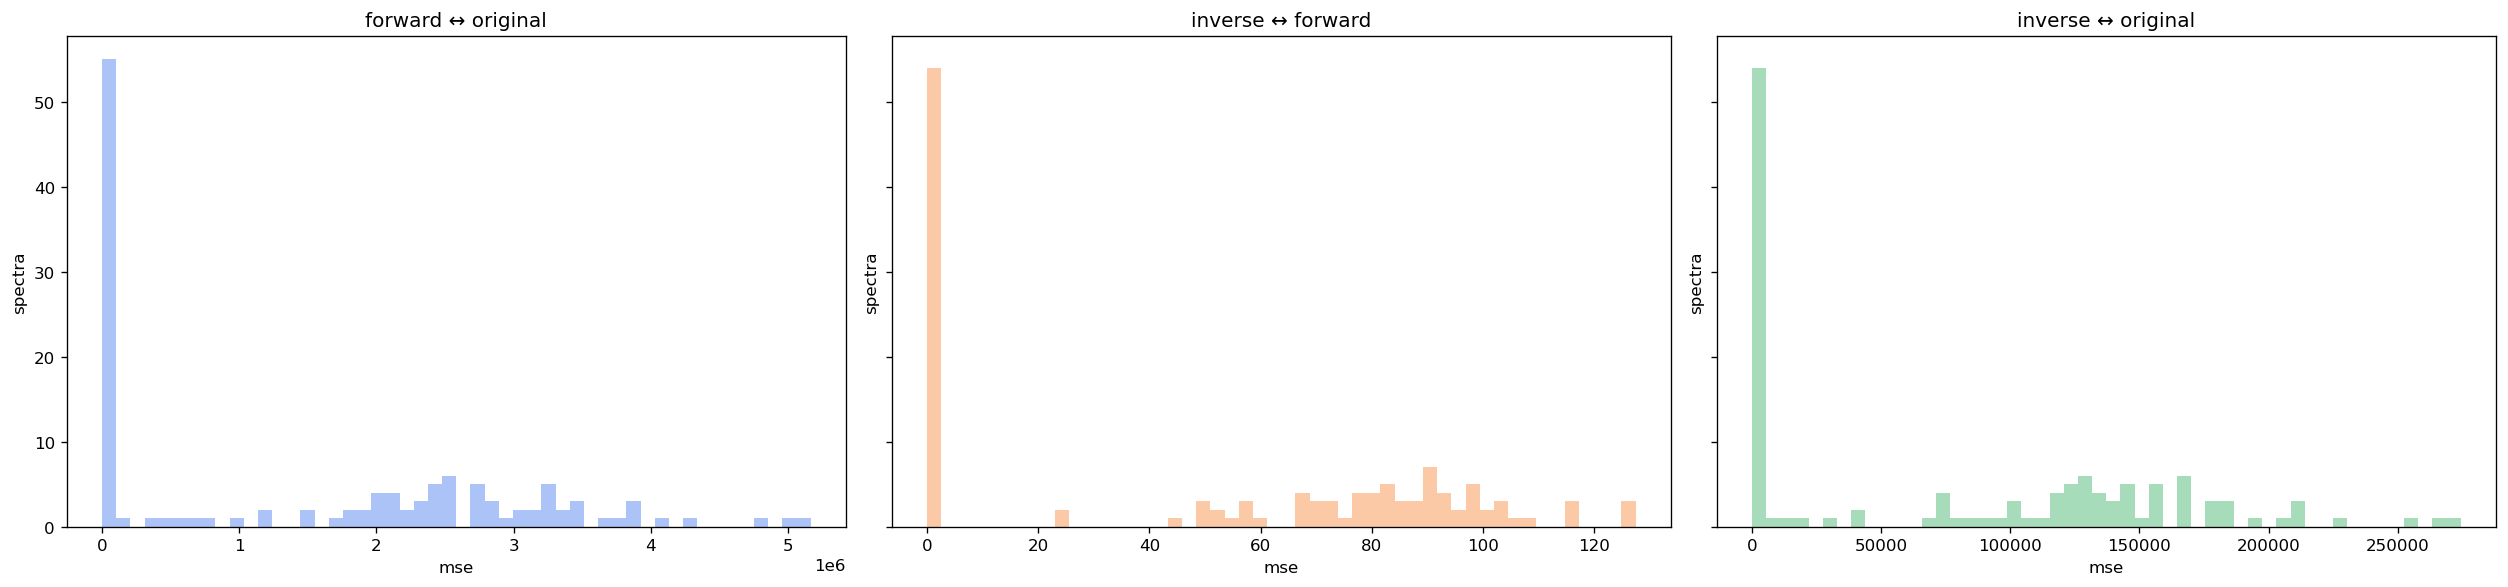

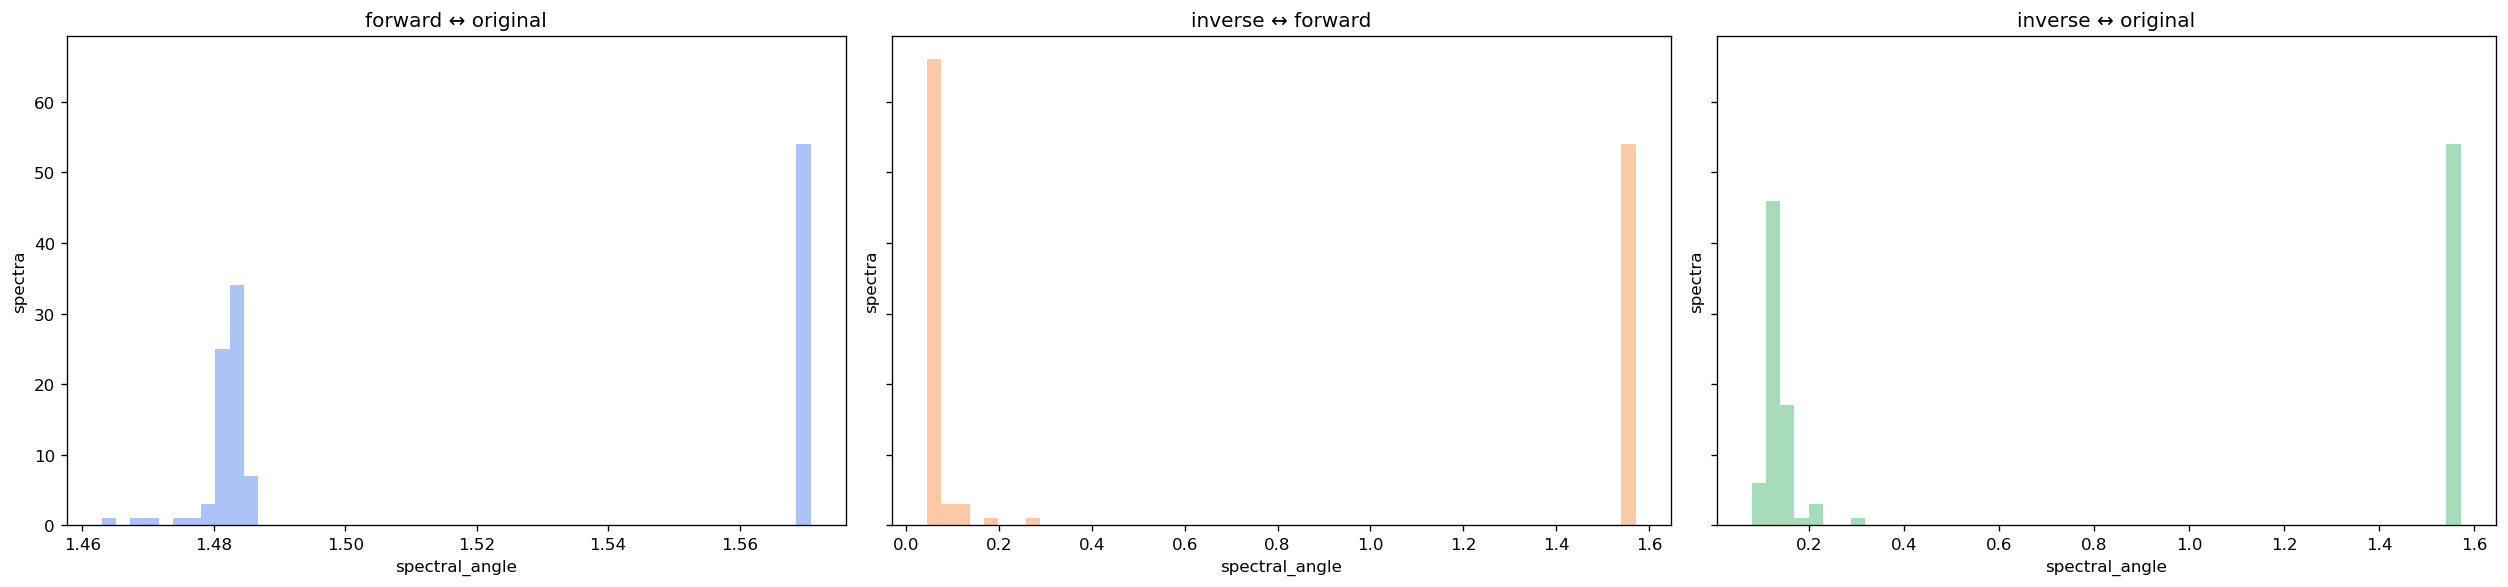

In [7]:
analysis.binning.plot_metric_distributions('mse', spectrum_ids=spectrum_ids)
analysis.binning.plot_metric_distributions('spectral_angle', spectrum_ids=spectrum_ids)

## Best, median, and worst reconstructed spectra

(<Figure size 840x720 with 1 Axes>,
 array([<Axes: title={'center': 'inverse_original: global mse distribution'}, xlabel='m/z', ylabel='mse'>],
       dtype=object),
 {'inverse_original': array([3203, 3204, 3205, 3206, 3207, 3208, 3209, 3210, 3211, 3212])})

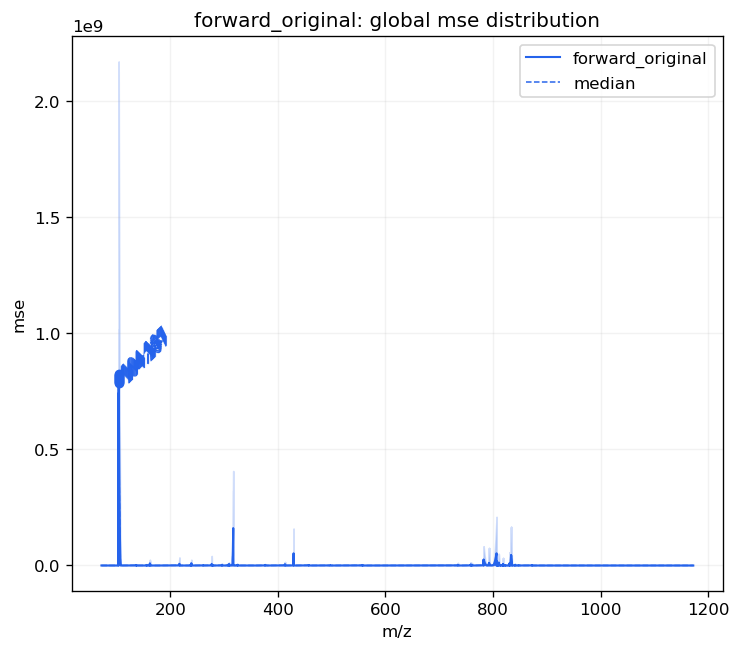

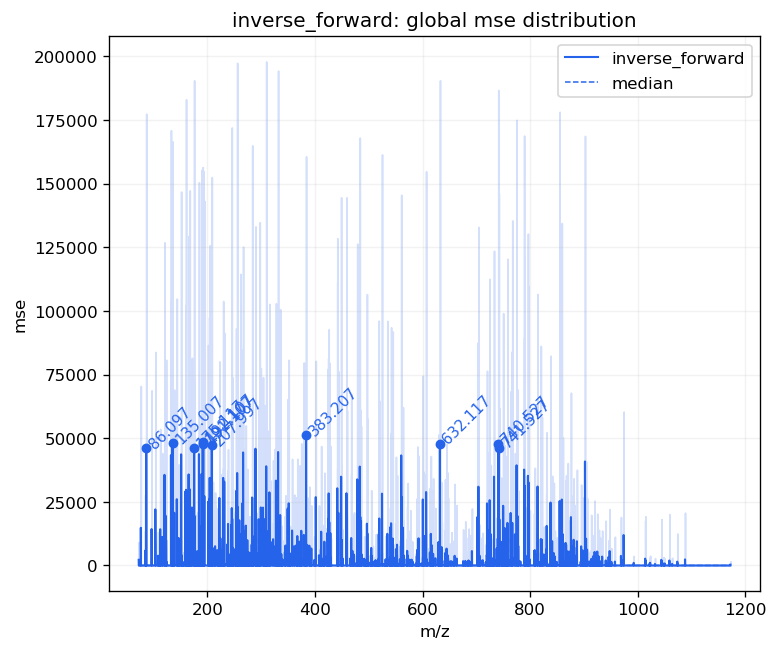

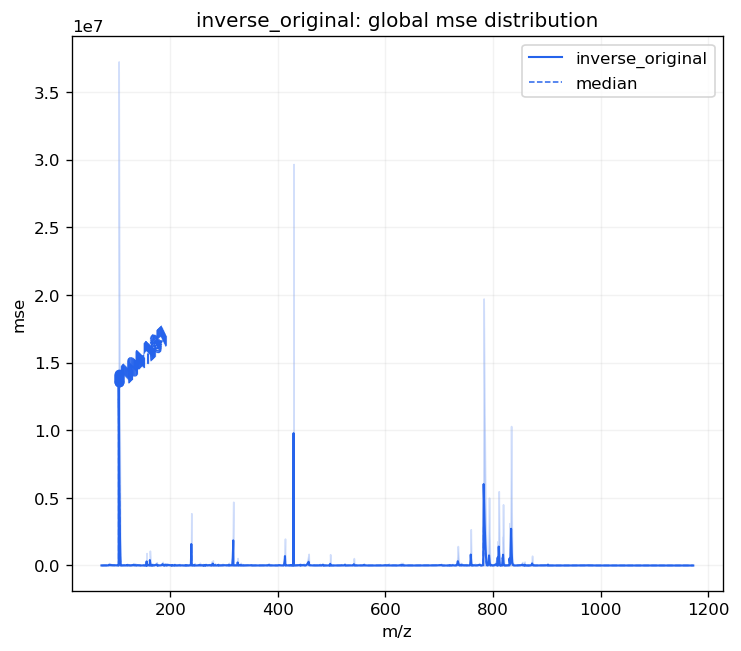

In [8]:
analysis.binning.plot_feature_error('forward_original', spectrum_ids=spectrum_ids, metric='mse', top_n=10)
analysis.binning.plot_feature_error('inverse_forward', spectrum_ids=spectrum_ids, metric='mse', top_n=10)
analysis.binning.plot_feature_error('inverse_original', spectrum_ids=spectrum_ids, metric='mse', top_n=10)

(<Figure size 3600x720 with 10 Axes>,
 array([[<Axes: title={'left': 'worst: spectrum 2505\nscore=5.164e+06'}, ylabel='forward_original\nintensity'>,
         <Axes: title={'left': 'worst: spectrum 1161\nscore=5.032e+06'}, ylabel='forward_original\nintensity'>,
         <Axes: title={'left': 'worst: spectrum 1786\nscore=4.785e+06'}, ylabel='forward_original\nintensity'>,
         <Axes: title={'left': 'worst: spectrum 1444\nscore=4.312e+06'}, ylabel='forward_original\nintensity'>,
         <Axes: title={'left': 'worst: spectrum 2610\nscore=4.130e+06'}, ylabel='forward_original\nintensity'>],
        [<Axes: xlabel='m/z', ylabel='residual'>,
         <Axes: xlabel='m/z', ylabel='residual'>,
         <Axes: xlabel='m/z', ylabel='residual'>,
         <Axes: xlabel='m/z', ylabel='residual'>,
         <Axes: xlabel='m/z', ylabel='residual'>]], dtype=object))

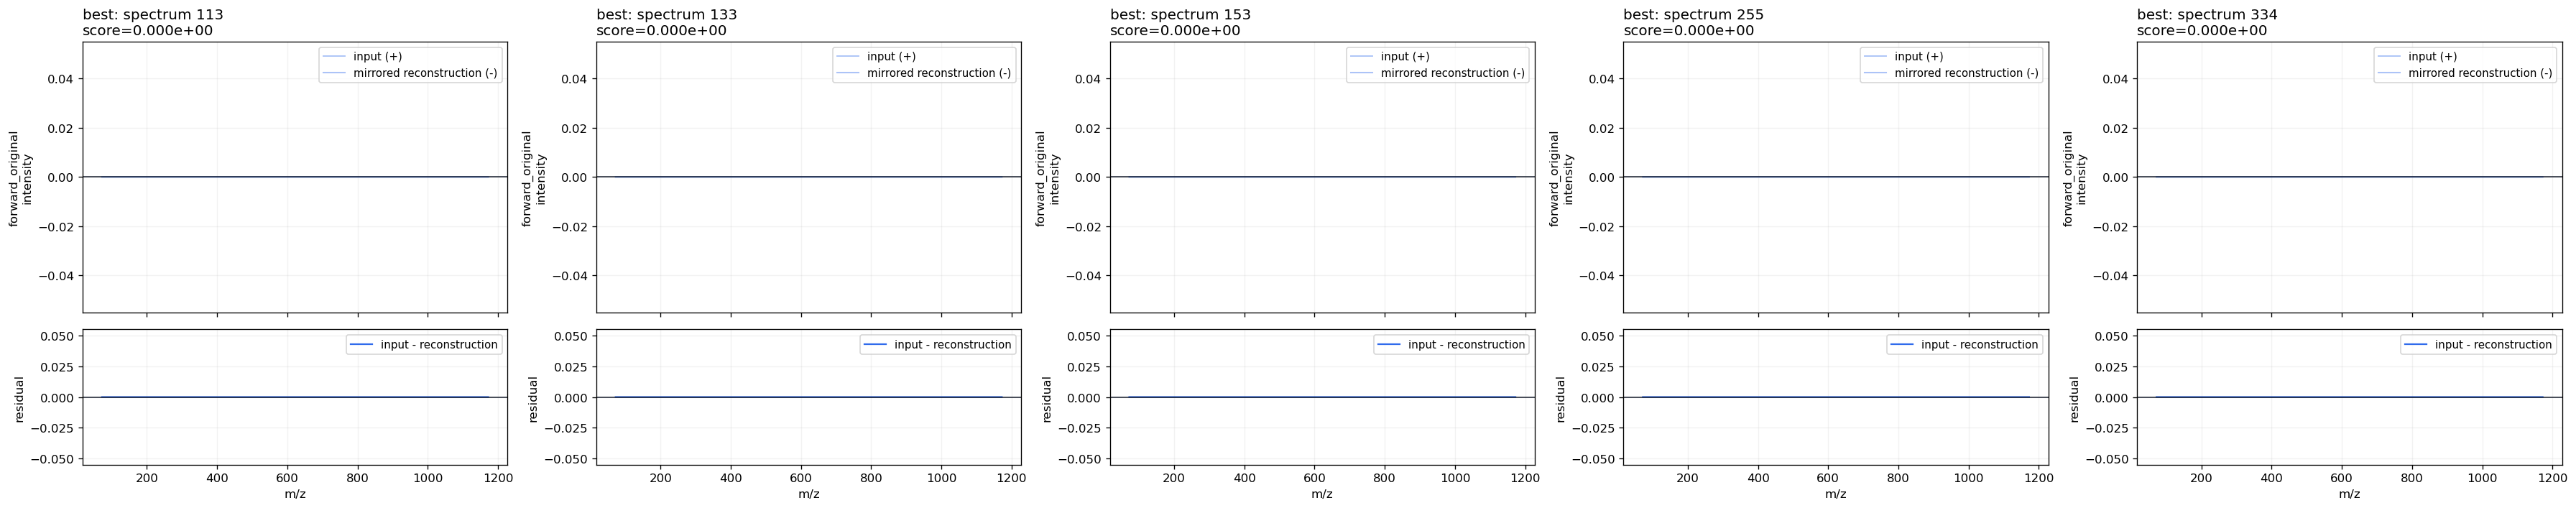

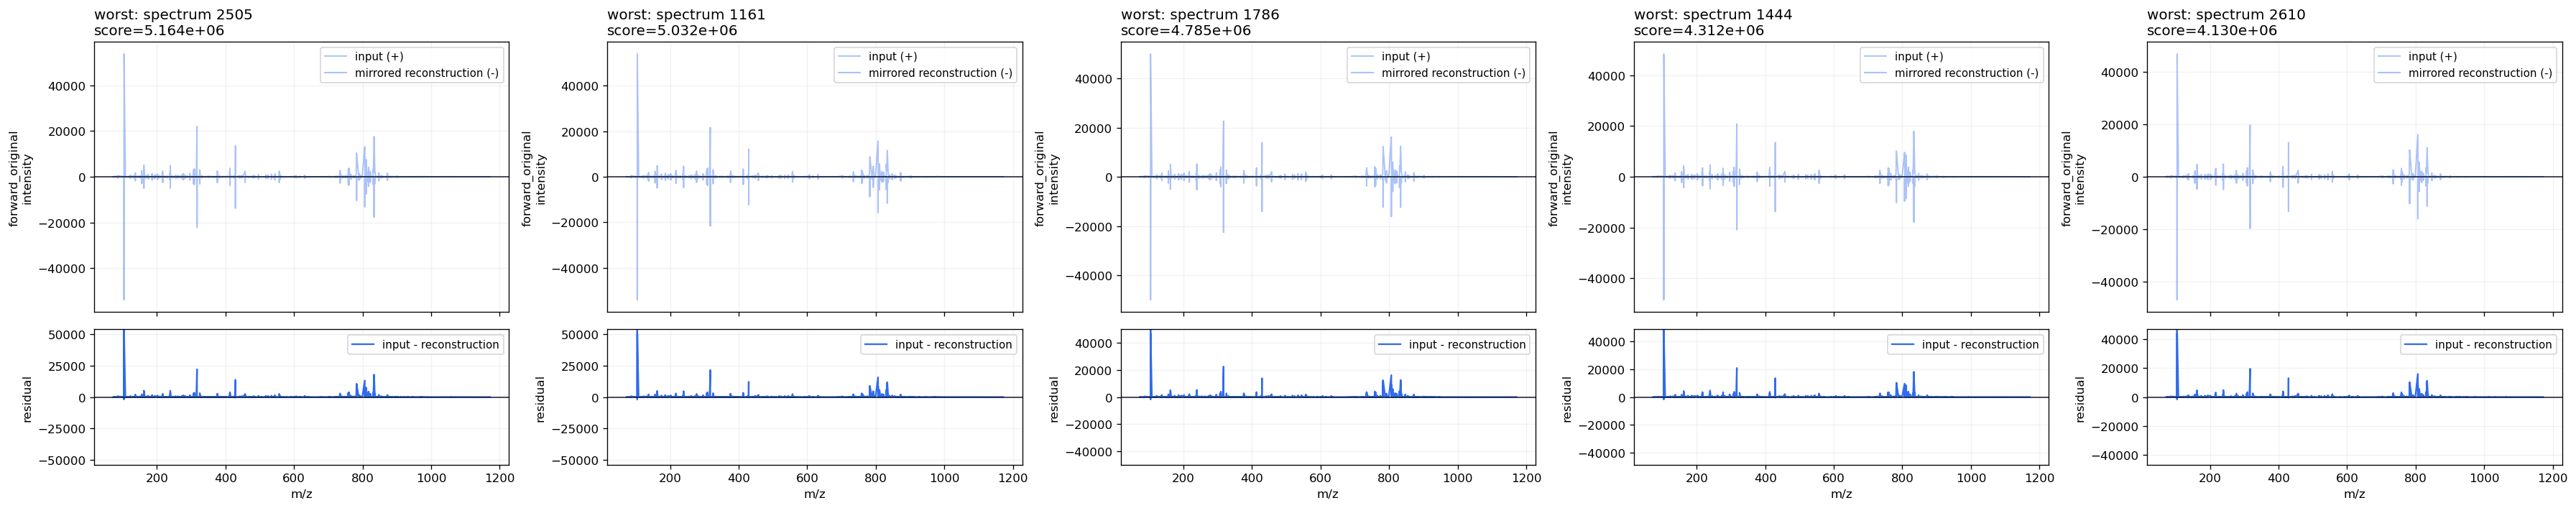

In [9]:
analysis.binning.plot_selected_spectra('forward_original', metric='mse', selection='best', count=5, spectrum_ids=spectrum_ids)
analysis.binning.plot_selected_spectra('forward_original', metric='mse', selection='worst', count=5, spectrum_ids=spectrum_ids)

(<Figure size 3600x720 with 10 Axes>,
 array([[<Axes: title={'left': 'worst: spectrum 1161\nscore=1.274e+02'}, ylabel='inverse_forward\nintensity'>,
         <Axes: title={'left': 'worst: spectrum 1786\nscore=1.261e+02'}, ylabel='inverse_forward\nintensity'>,
         <Axes: title={'left': 'worst: spectrum 2505\nscore=1.258e+02'}, ylabel='inverse_forward\nintensity'>,
         <Axes: title={'left': 'worst: spectrum 1444\nscore=1.171e+02'}, ylabel='inverse_forward\nintensity'>,
         <Axes: title={'left': 'worst: spectrum 3629\nscore=1.165e+02'}, ylabel='inverse_forward\nintensity'>],
        [<Axes: xlabel='m/z', ylabel='residual'>,
         <Axes: xlabel='m/z', ylabel='residual'>,
         <Axes: xlabel='m/z', ylabel='residual'>,
         <Axes: xlabel='m/z', ylabel='residual'>,
         <Axes: xlabel='m/z', ylabel='residual'>]], dtype=object))

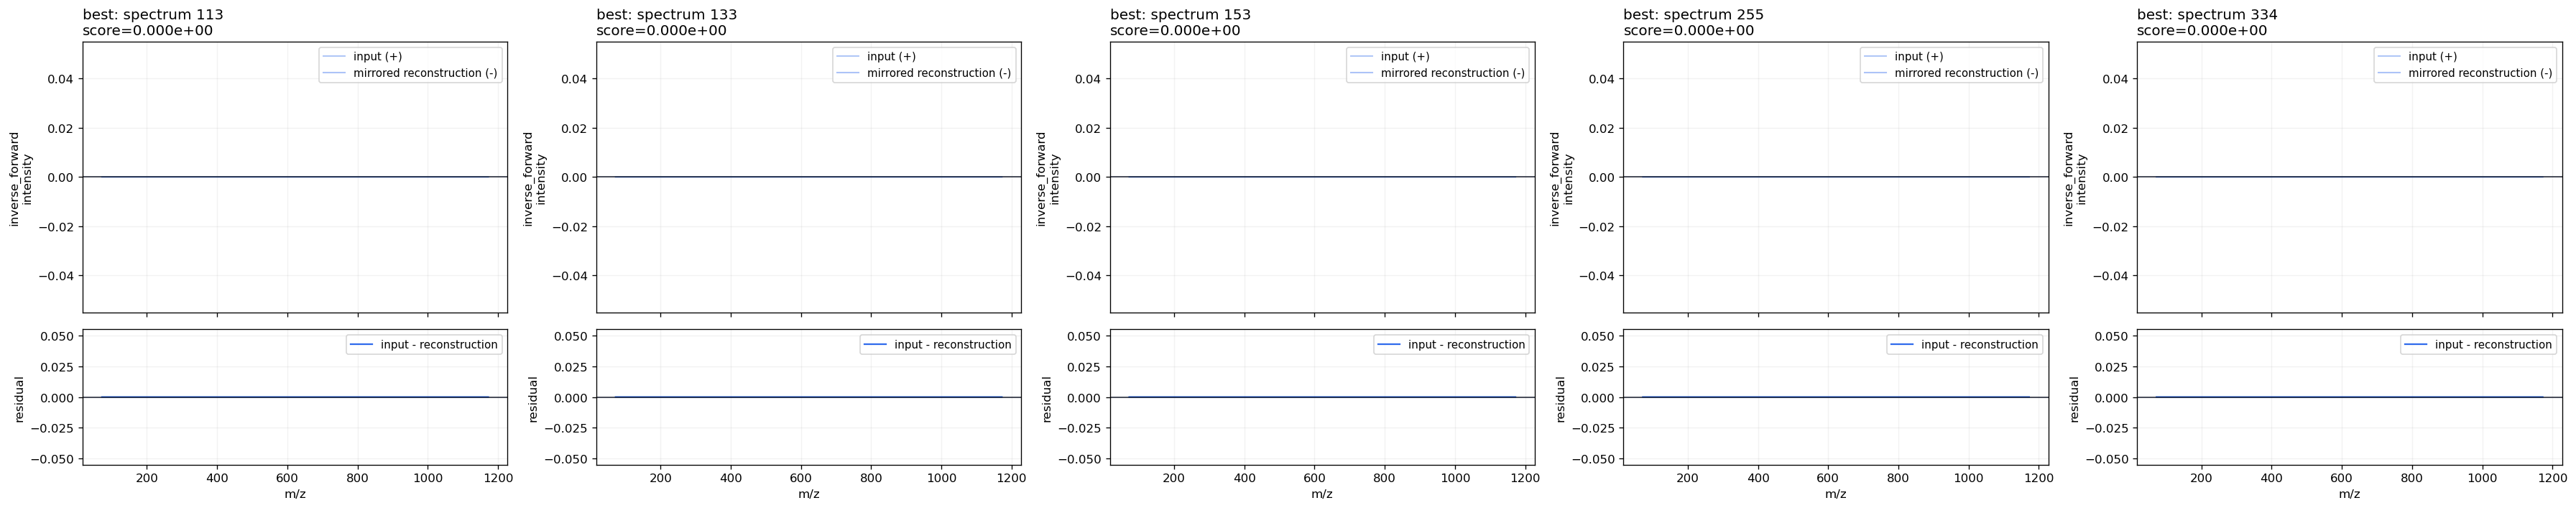

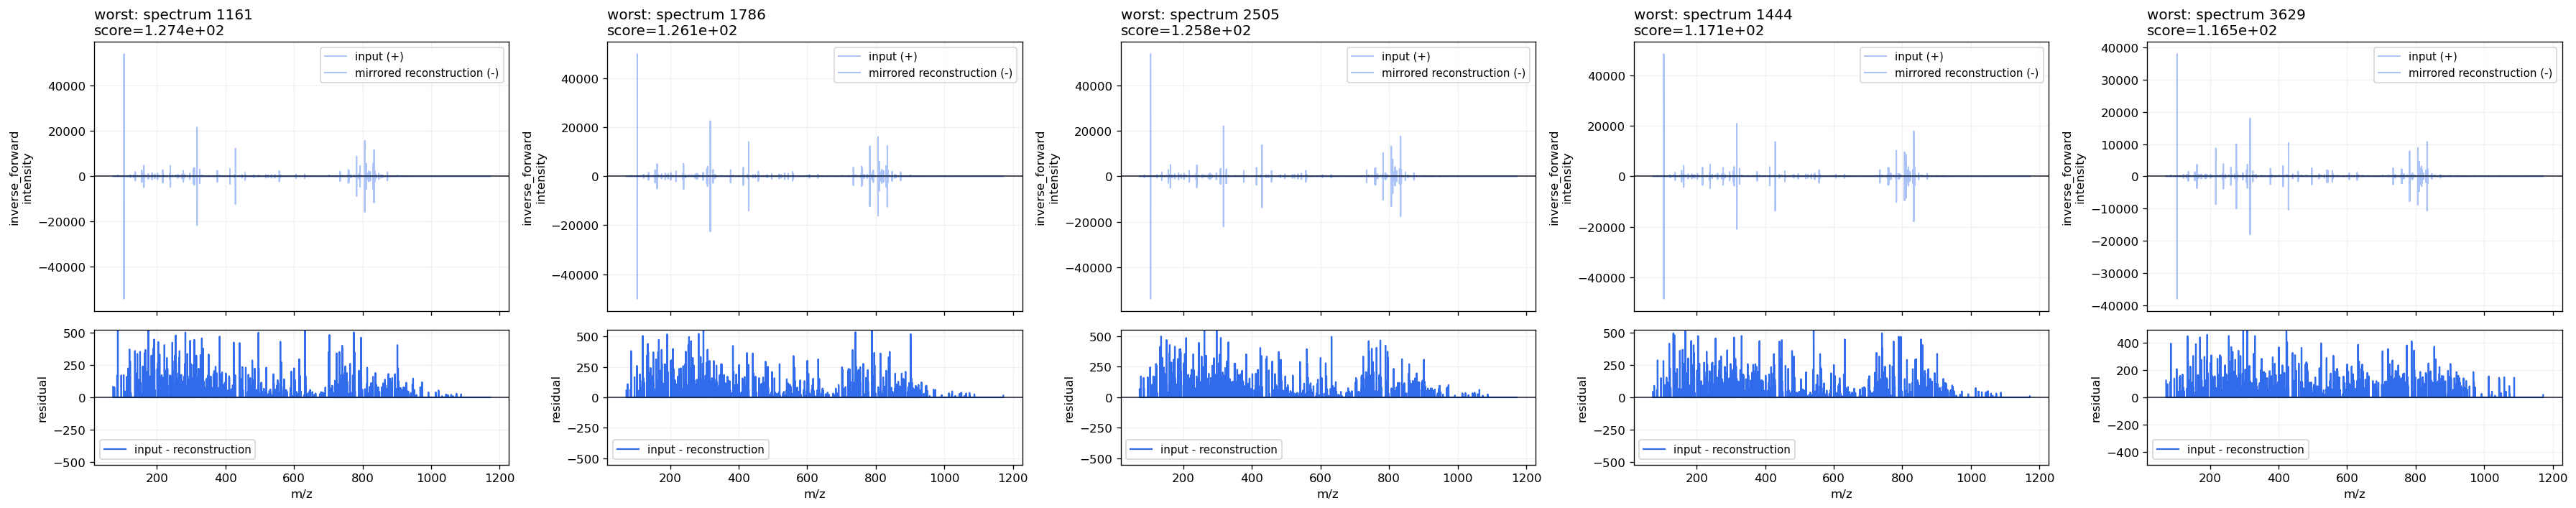

In [10]:
analysis.binning.plot_selected_spectra('inverse_forward', metric='mse', selection='best', count=5, spectrum_ids=spectrum_ids)
analysis.binning.plot_selected_spectra('inverse_forward', metric='mse', selection='worst', count=5, spectrum_ids=spectrum_ids)

(<Figure size 3600x720 with 10 Axes>,
 array([[<Axes: title={'left': 'worst: spectrum 2505\nscore=2.744e+05'}, ylabel='inverse_original\nintensity'>,
         <Axes: title={'left': 'worst: spectrum 1786\nscore=2.649e+05'}, ylabel='inverse_original\nintensity'>,
         <Axes: title={'left': 'worst: spectrum 1444\nscore=2.565e+05'}, ylabel='inverse_original\nintensity'>,
         <Axes: title={'left': 'worst: spectrum 1161\nscore=2.292e+05'}, ylabel='inverse_original\nintensity'>,
         <Axes: title={'left': 'worst: spectrum 2610\nscore=2.134e+05'}, ylabel='inverse_original\nintensity'>],
        [<Axes: xlabel='m/z', ylabel='residual'>,
         <Axes: xlabel='m/z', ylabel='residual'>,
         <Axes: xlabel='m/z', ylabel='residual'>,
         <Axes: xlabel='m/z', ylabel='residual'>,
         <Axes: xlabel='m/z', ylabel='residual'>]], dtype=object))

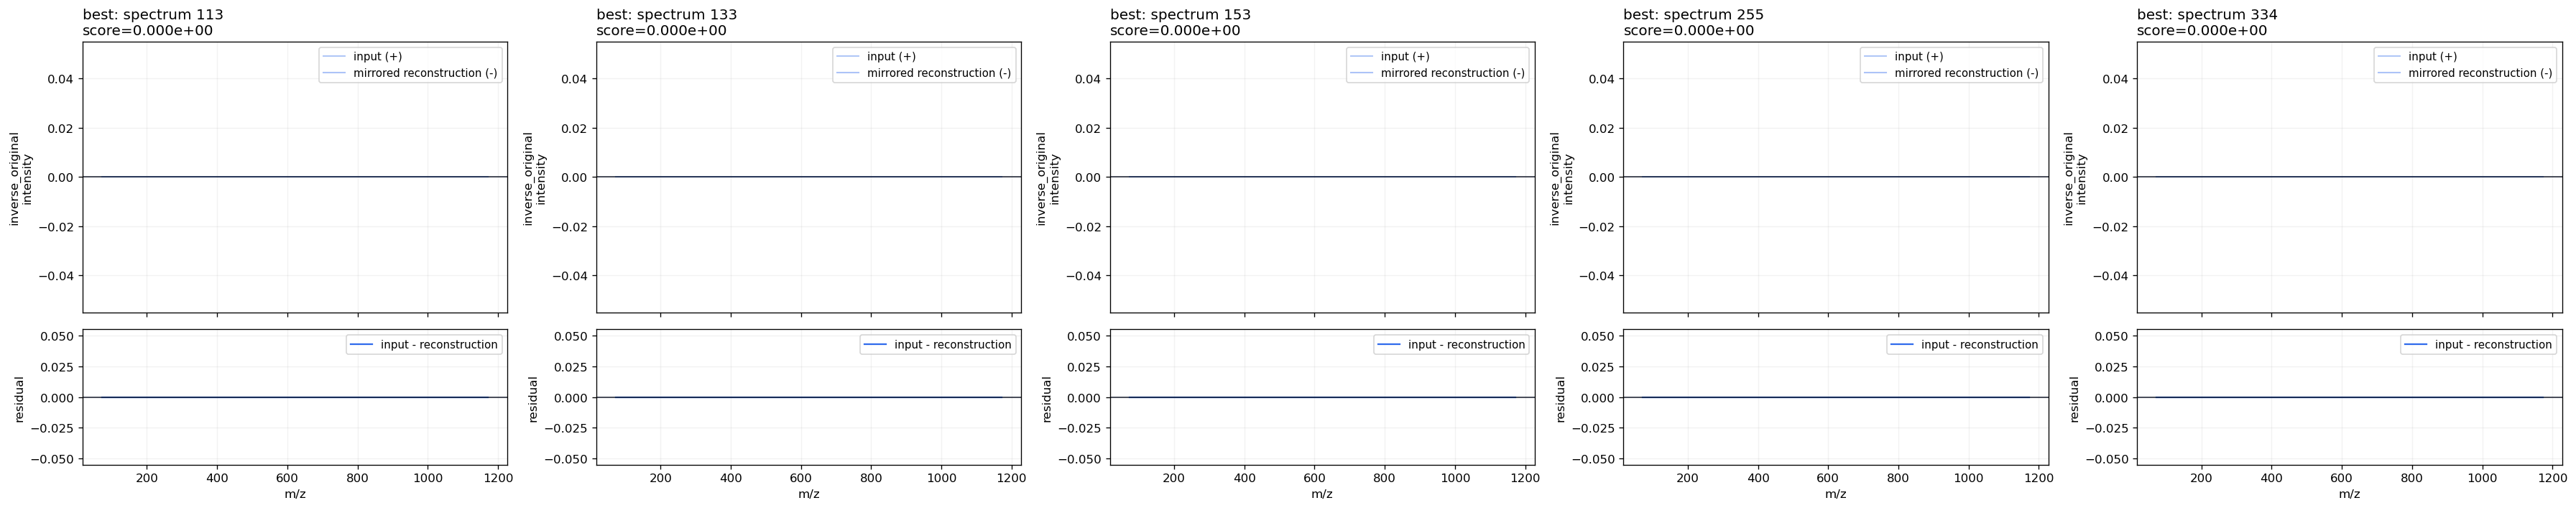

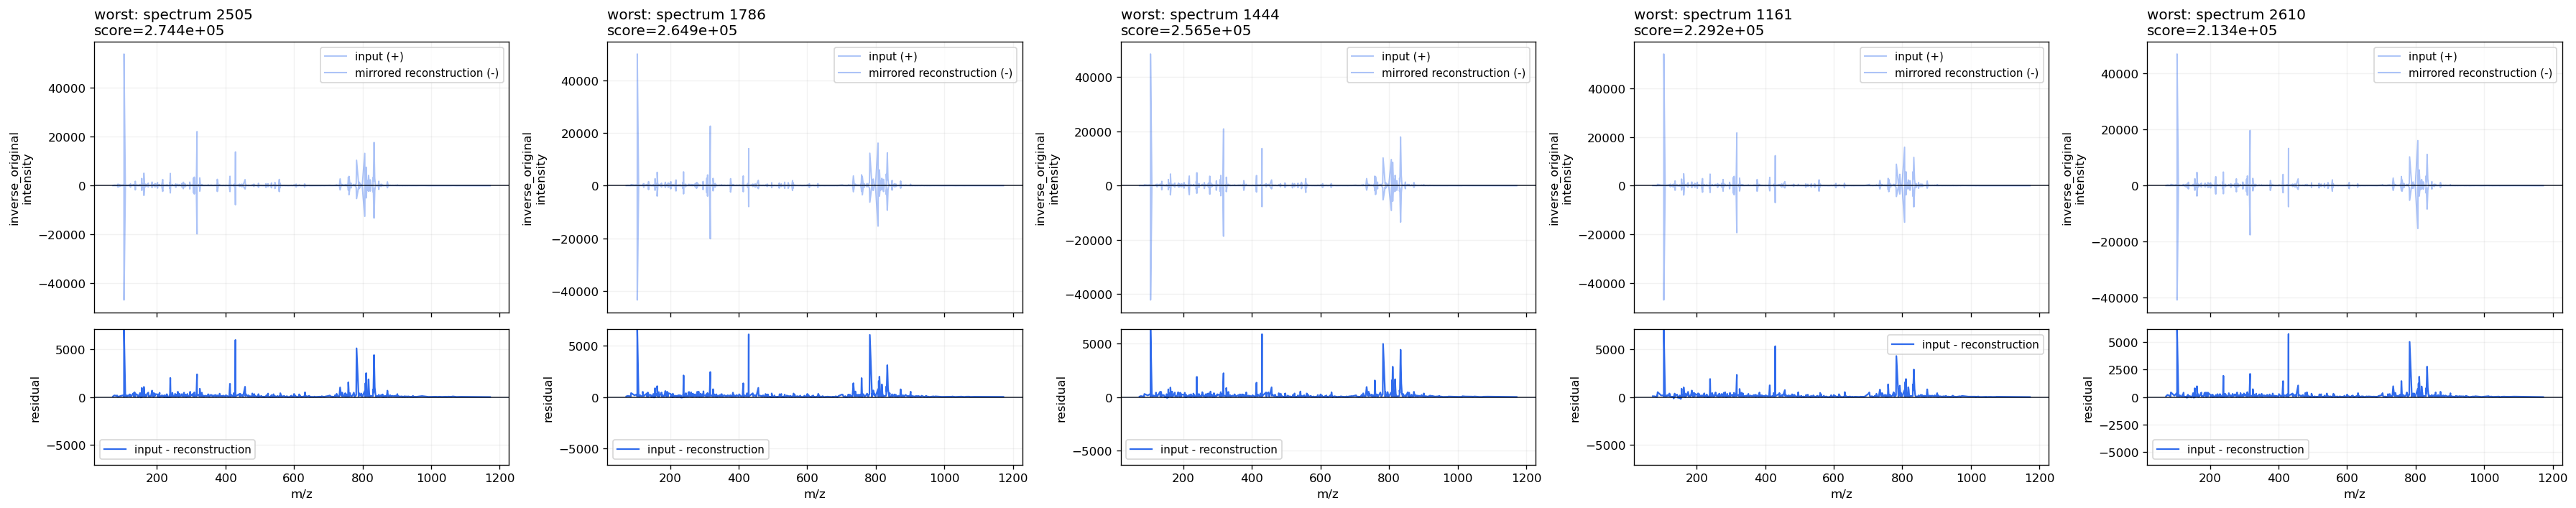

In [11]:
analysis.binning.plot_selected_spectra('inverse_original', metric='mse', selection='best', count=5, spectrum_ids=spectrum_ids)
analysis.binning.plot_selected_spectra('inverse_original', metric='mse', selection='worst', count=5, spectrum_ids=spectrum_ids)

## Training-compatible Masserstein metric
Run this separately because optimal transport is substantially more expensive than pointwise metrics.

In [12]:
transport_subset = spectrum_ids[:min(16, len(spectrum_ids))]
transport_summary = pd.DataFrame(analysis.binning.metric_summaries(
    spectrum_ids=transport_subset, include_masserstein=True,
))
transport_summary[transport_summary['metric'] == 'masserstein']

2026-07-30 11:05:22,228 | WARNING  | msi_autoencoder_wrapper.training.criterions.autoencoder.reconstruction.masserstein_loss:431 | Masserstein loss received an irregular axis; using the chunked quadratic-time kernel fallback.


/home/maxi7524/repositories/MSIAutoEncoderWrapper/src/msi_autoencoder_wrapper/analysis/autoencoder/reconstruction/metrics.py:77: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  criterion._mass_axis = torch.as_tensor(axis, dtype=torch.float64, device=device)


2026-07-30 11:05:23,812 | WARNING  | msi_autoencoder_wrapper.training.criterions.autoencoder.reconstruction.masserstein_loss:431 | Masserstein loss received an irregular axis; using the chunked quadratic-time kernel fallback.
2026-07-30 11:05:25,298 | WARNING  | msi_autoencoder_wrapper.training.criterions.autoencoder.reconstruction.masserstein_loss:431 | Masserstein loss received an irregular axis; using the chunked quadratic-time kernel fallback.
2026-07-30 11:05:26,802 | WARNING  | msi_autoencoder_wrapper.training.criterions.autoencoder.reconstruction.masserstein_loss:431 | Masserstein loss received an irregular axis; using the chunked quadratic-time kernel fallback.
2026-07-30 11:05:28,285 | WARNING  | msi_autoencoder_wrapper.training.criterions.autoencoder.reconstruction.masserstein_loss:431 | Masserstein loss received an irregular axis; using the chunked quadratic-time kernel fallback.
2026-07-30 11:05:29,837 | WARNING  | msi_autoencoder_wrapper.training.criterions.autoencoder.rec

,comparison,metric,count,mean,std,min,q25,median,q75,max
5,forward_original,masserstein,16.0,0.121796,0.210956,0.0,0.0,0.0,0.121755,0.487287
11,inverse_forward,masserstein,16.0,0.032794,0.059108,0.0,0.0,0.0,0.025754,0.186790
17,inverse_original,masserstein,16.0,0.047637,0.083598,0.0,0.0,0.0,0.041683,0.236223
